## Analyzing Factors for Objective Evaluation of Soccer Players Across Eras  

Student:     **Omar De La Rosa**

### Business Understanding
Soccer’s evolution has brought about significant changes in playstyle, tactics, and player roles. This has made it difficult to objectively compare players from different generations, especially when traditional metrics like goal tallies and trophies favor modern players who benefit from advancements in sports science and expanded opportunities to compete. Such biases not only distort historical rankings but also limit the effectiveness of modern talent scouting and analysis.

This capstone project seeks to establish a systematic, data-driven framework for evaluating soccer players across eras by focusing on individual attributes rather than team-based accolades. Leveraging machine learning, particularly the XGBoost model, the project aims to analyze variables such as physical ability, technical skill, and in-game performance. The goal is to create a fairer ranking system that accounts for generational differences while providing actionable insights for talent acquisition and historical comparisons.

The findings from this research could significantly impact how players are evaluated and ranked, offering a new standard for fairness and accuracy in sports analytics. By providing a comprehensive, attribute-based evaluation, this project can bridge the gap between generations and support better decision-making in talent scouting and historical assessments.

### *Research Question: How can soccer players from different eras be evaluated objectively and fairly using a data-driven approach?*


### Data Understanding
The dataset used for this project is derived from FIFA, a widely recognized soccer video game that provides detailed player statistics and attributes for professional players. This dataset contains a rich set of variables capturing the physical, technical, and mental attributes of players, along with metadata like player name, club, and nationality.

The variables in the dataset include:

- **Overall**: The overall rating of the player.
- **Potential**: The player's potential rating.
- **Physical Attributes**: Characteristics such as stamina, strength, and jumping ability.
- **Technical Skills**: Attributes like passing accuracy, dribbling, and finishing.
- **Mental Attributes**: Vision, composure, and positioning.
- **Position-Specific Metrics**: Attributes tailored for roles such as Goalkeeper reflexes and Diving.
- **Metadata**: Information such as player name, club, and nationality.

This dataset enables a comprehensive analysis of player attributes across generations, allowing for the creation of position-specific scores and the training of machine learning models to predict and evaluate player roles.

### Data Preparation
In this section, we will focus on preparing the FIFA dataset for further analysis. Data preparation is a crucial step to ensure the reliability and accuracy of our findings. We address various aspects of data cleaning and preprocessing to ensure the dataset is in an optimal state for exploration and modeling.

In this code, we perform the following steps for data preparation:

1. **Add Position-Specific Scores**: We calculate scores for each position (Defender, Midfielder, Forward, Goalkeeper) based on relevant attributes such as Defensive Awareness, Passing, Dribbling, Reflexes, etc.

2. **Assign Positions**: Using the calculated position-specific scores, we assign each player a position by selecting the role with the highest score.

3. **Remove Players with Unknown Positions**: We eliminate rows where a position could not be determined, ensuring the dataset contains only valid player roles.

4. **Encode Target Variable**: We encode the assigned positions into numeric labels for use in machine learning models.

5. **Select Relevant Features**: We retain only key attributes, such as Overall ratings, position-specific features, and metadata (Name, Club), for modeling and analysis.

6. **Split Dataset**: We split the dataset into training and testing sets to prepare for model development and evaluation.

These steps ensure the dataset is clean, structured, and ready for advanced modeling tasks while maintaining the integrity of positional roles and player attributes.


In [2]:
# Load libraries
%pip install xgboost
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
data_path = "C:/Users/odlr/OneDrive/Davenport/Data Capstone/fifa_23_280922.csv"
data = pd.read_csv(data_path)

# Check data dimensions and first few rows
print("Data loaded successfully")
print(data.shape)
print(data.head())

# Select relevant features
features = [
    'Overall', 'Potential', 'Crossing', 'Finishing', 'Short passing', 'Dribbling',
    'Ball control', 'Acceleration', 'Sprint speed', 'Stamina', 'Strength', 
    'Defensive awareness', 'Standing tackle', 'Sliding tackle', 'Interceptions', 
    'Diving', 'Handling', 'Kicking', 'Positioning (GK)', 'Reflexes', 'Heading accuracy', 
    'Curve', 'Free kick accuracy', 'Long passing', 'Agility', 'Reactions', 'Balance', 
    'Shot power', 'Jumping', 'Aggression', 'Positioning', 'Vision', 'Penalties', 'Composure'
]

# Select columns and convert them to numeric
features_data = data[features].apply(pd.to_numeric, errors='coerce')

# Verify selected features
print("Selected features:")
print(features_data.head())

# Add scores for each position
data['Defender_score'] = (
    data['Defensive awareness'] + data['Standing tackle'] + data['Sliding tackle'] +
    data['Aggression'] + data['Strength'] + data['Interceptions']
)

data['Midfielder_score'] = (
    data['Short passing'] + data['Stamina'] + data['Heading accuracy'] +
    data['Long passing'] + data['Balance'] + data['Vision'] + data['Composure']
)

data['Forward_score'] = (
    data['Finishing'] + data['Acceleration'] + data['Sprint speed'] +
    data['Dribbling'] + data['Shot power'] + data['Reactions'] +
    data['Agility'] + data['Crossing'] + data['Free kick accuracy'] + data['Composure']
)

data['Goalkeeper_score'] = (
    data['Diving'] + data['Handling'] + data['Kicking'] + 
    data['Positioning (GK)'] + data['Reflexes']
)

# Assign positions based on highest scores
data['Position'] = np.select(
    [
        (data['Defender_score'] >= data[['Midfielder_score', 'Forward_score', 'Goalkeeper_score']].max(axis=1)),
        (data['Midfielder_score'] >= data[['Defender_score', 'Forward_score', 'Goalkeeper_score']].max(axis=1)),
        (data['Forward_score'] >= data[['Defender_score', 'Midfielder_score', 'Goalkeeper_score']].max(axis=1)),
        (data['Goalkeeper_score'] >= data[['Defender_score', 'Midfielder_score', 'Forward_score']].max(axis=1))
    ],
    ['Defender', 'Midfielder', 'Forward', 'Goalkeeper'],
    default='Unknown'
)

# Remove unknown positions
data = data[data['Position'] != 'Unknown']

# Encode Position as numeric
encoder = LabelEncoder()
data['Position_encoded'] = encoder.fit_transform(data['Position'])

# Compile top 100 players for each position
top_players = {
    pos: data[data['Position'] == pos].nlargest(100, f'{pos}_score')
    for pos in ['Defender', 'Midfielder', 'Forward', 'Goalkeeper']
}

# Combine into balanced dataset
balanced_data = pd.concat(top_players.values(), ignore_index=True)
print("Balanced dataset prepared:")
print(balanced_data['Position'].value_counts())



   ---------------------------------------- 0.0/124.9 MB ? eta -:--:--
   - -------------------------------------- 5.5/124.9 MB 33.6 MB/s eta 0:00:04
   ----- ---------------------------------- 18.1/124.9 MB 49.5 MB/s eta 0:00:03
   --------- ------------------------------ 28.6/124.9 MB 49.0 MB/s eta 0:00:02
   ------------- -------------------------- 40.9/124.9 MB 52.0 MB/s eta 0:00:02
   ---------------- ----------------------- 52.4/124.9 MB 52.2 MB/s eta 0:00:02
   ------------------- -------------------- 62.1/124.9 MB 50.8 MB/s eta 0:00:02
   ----------------------- ---------------- 74.4/124.9 MB 51.6 MB/s eta 0:00:01
   --------------------------- ------------ 87.3/124.9 MB 53.0 MB/s eta 0:00:01
   ------------------------------- ------- 100.1/124.9 MB 54.2 MB/s eta 0:00:01
   ---------------------------------- ---- 110.4/124.9 MB 53.4 MB/s eta 0:00:01
   ------------------------------------- - 119.5/124.9 MB 52.3 MB/s eta 0:00:01
   --------------------------------------  124.8/

### Exploratory Data Analysis (EDA)
Perform various visualizations to explore and gain insights from the FIFA dataset:

1. **Position Distribution:** We use a count plot to visualize the distribution of player positions (Defender, Midfielder, Forward, Goalkeeper) in the balanced dataset.
2. **Overall Rating by Position:**: We create a box plot to compare the distribution of Overall ratings across different player positions, providing insights into positional differences in player quality.
3. **Feature Correlation Heatmap:**: We generate a heatmap to examine correlations among selected features, helping to identify relationships between key attributes such as Overall, Strength, Vision, and others.

These visualizations provide a comprehensive understanding of the data's structure, relationships, and patterns, enabling us to make informed decisions for model development and analysis.

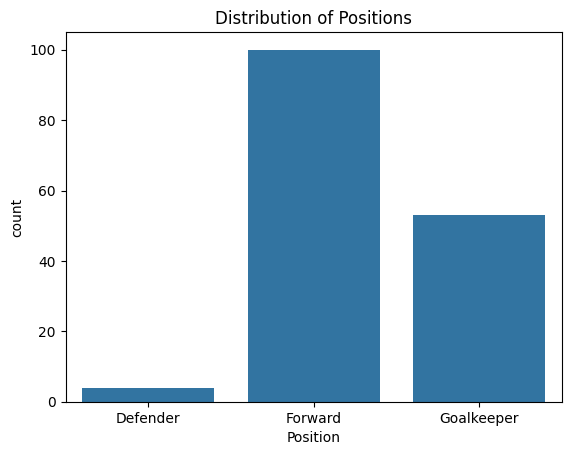

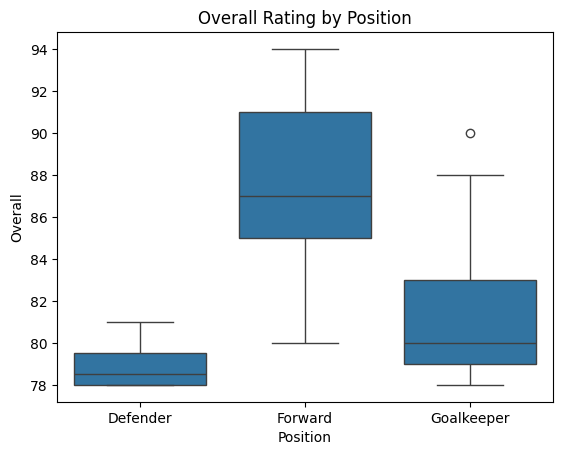

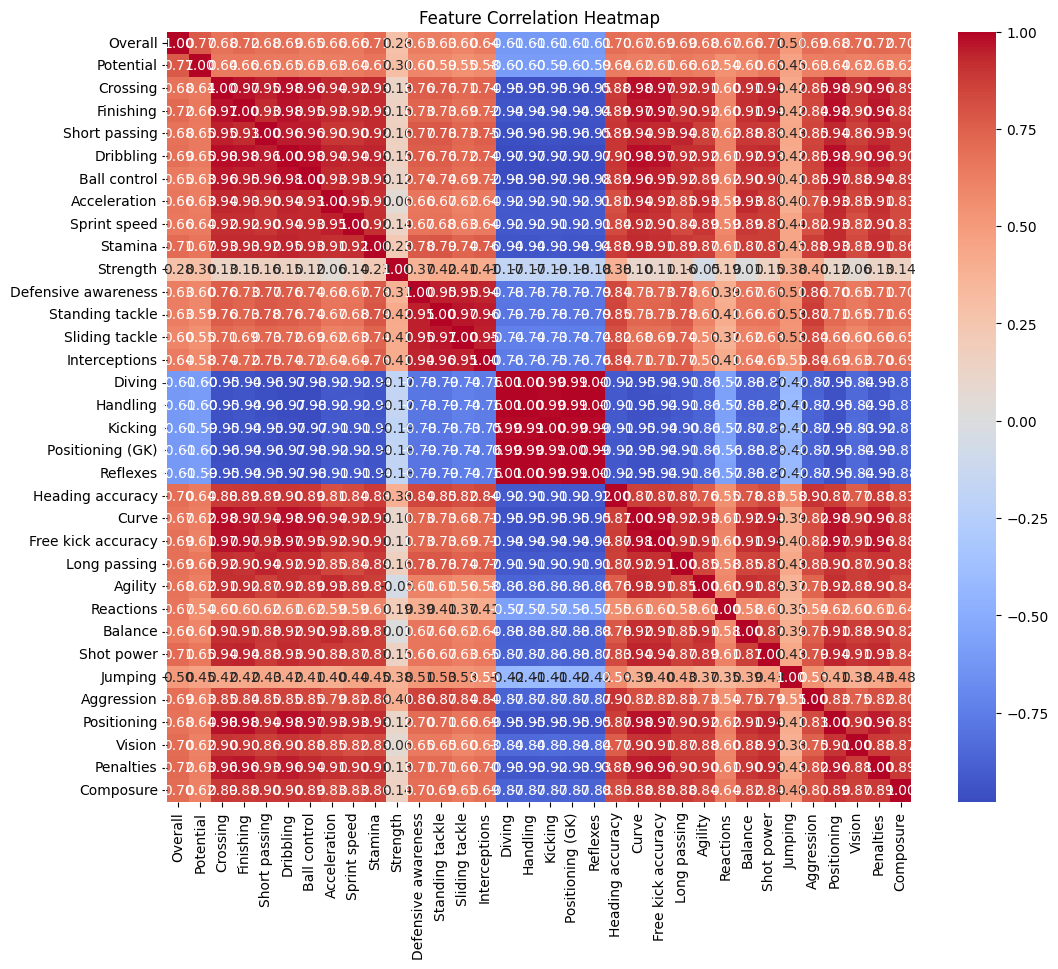

In [3]:
# Visualize position distribution
sns.countplot(x='Position', data=balanced_data)
plt.title("Distribution of Positions")
plt.show()

# Visualize Overall rating by Position
sns.boxplot(x='Position', y='Overall', data=balanced_data)
plt.title("Overall Rating by Position")
plt.show()

# Correlation heatmap of selected features
corr_matrix = balanced_data[features].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()


### Modeling
In this section, we will apply various modeling techniques to analyze the FIFA dataset and predict the best 11 Players outcomes based on the available features. Our objective is to build models that can effectively capture the underlying patterns and relationships in the data, enabling accurate predictions and insights.

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Split data into train and test sets
X = balanced_data[features]
y = balanced_data['Position_encoded']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions
rf_predictions = rf_model.predict(X_test)

# Evaluate performance
rf_accuracy = accuracy_score(y_test, rf_predictions)
print("Random Forest Model Accuracy:", rf_accuracy)
print(classification_report(y_test, rf_predictions))


Random Forest Model Accuracy: 1.0
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        20
           2       1.00      1.00      1.00        12

    accuracy                           1.00        32
   macro avg       1.00      1.00      1.00        32
weighted avg       1.00      1.00      1.00        32



### Evaluation
In this section, we will evaluate the performance of our models and assess their ability to accurately predict survival outcomes based on the FIFA dataset. The evaluation stage is crucial for understanding the effectiveness and reliability of our models in addressing the research question.

- Confusion Matrix:  Visualize the performance of a classification model by displaying the counts of true positive, true negative, false positive, and false negative predictions.  
- Receiver Operating Characteristic (ROC) Curve: Illustrates the trade-off between true positive rate (sensitivity) and false positive rate (1 - specificity) for different classification thresholds.
- Precision-Recall Curve: Shows the relationship between precision and recall (sensitivity) for different classification thresholds.

#### XGBoost model

[0]	train-mlogloss:0.86919	test-mlogloss:0.88290
[1]	train-mlogloss:0.59917	test-mlogloss:0.62015
[2]	train-mlogloss:0.42763	test-mlogloss:0.46037
[3]	train-mlogloss:0.31170	test-mlogloss:0.34743
[4]	train-mlogloss:0.23036	test-mlogloss:0.27047
[5]	train-mlogloss:0.17192	test-mlogloss:0.21307
[6]	train-mlogloss:0.12849	test-mlogloss:0.16939
[7]	train-mlogloss:0.09748	test-mlogloss:0.13949
[8]	train-mlogloss:0.07489	test-mlogloss:0.11819
[9]	train-mlogloss:0.05775	test-mlogloss:0.10076
[10]	train-mlogloss:0.04497	test-mlogloss:0.08882
[11]	train-mlogloss:0.03500	test-mlogloss:0.07974
[12]	train-mlogloss:0.02783	test-mlogloss:0.07397
[13]	train-mlogloss:0.02259	test-mlogloss:0.06793
[14]	train-mlogloss:0.01844	test-mlogloss:0.06412
[15]	train-mlogloss:0.01511	test-mlogloss:0.05910
[16]	train-mlogloss:0.01273	test-mlogloss:0.05539
[17]	train-mlogloss:0.01103	test-mlogloss:0.05288
[18]	train-mlogloss:0.00951	test-mlogloss:0.05193
[19]	train-mlogloss:0.00831	test-mlogloss:0.05077
[20]	train

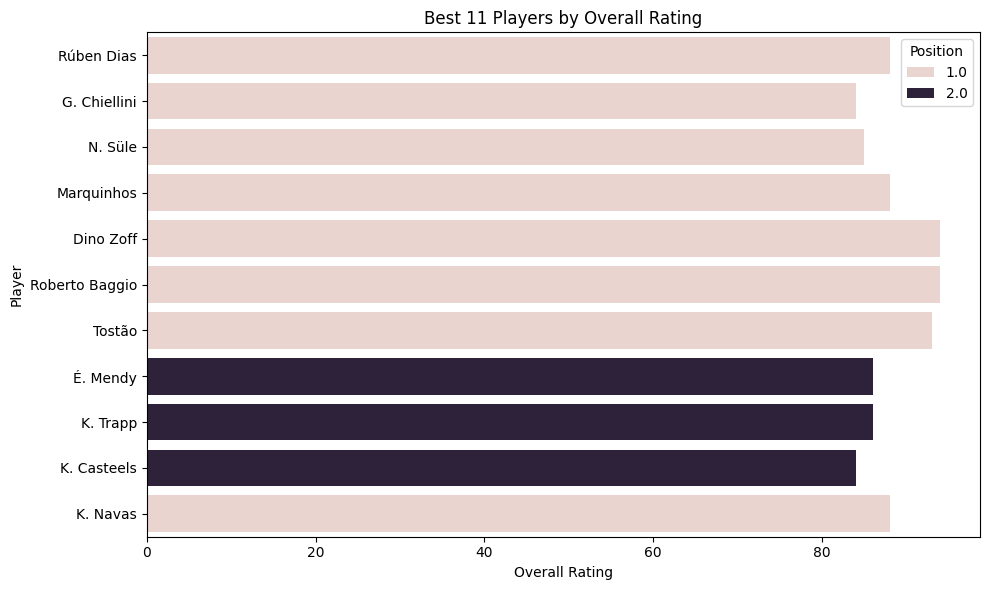

In [45]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Add position-specific scores
position_scores = ['Defender_score', 'Midfielder_score', 'Forward_score', 'Goalkeeper_score']
if not all(col in data.columns for col in position_scores):
    data['Defender_score'] = (
        data['Defensive awareness'] + data['Standing tackle'] + data['Sliding tackle'] +
        data['Aggression'] + data['Strength'] + data['Interceptions']
    )
    data['Midfielder_score'] = (
        data['Short passing'] + data['Stamina'] + data['Heading accuracy'] +
        data['Long passing'] + data['Balance'] + data['Vision'] + data['Composure']
    )
    data['Forward_score'] = (
        data['Finishing'] + data['Acceleration'] + data['Sprint speed'] +
        data['Dribbling'] + data['Shot power'] + data['Reactions'] +
        data['Agility'] + data['Crossing'] + data['Free kick accuracy'] + data['Composure']
    )
    data['Goalkeeper_score'] = (
        data['Diving'] + data['Handling'] + data['Kicking'] +
        data['Positioning (GK)'] + data['Reflexes']
    )

# Include metadata and scores in X
X = data[features + position_scores + ['Name', 'Club']]
y = data['Position_encoded']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train XGBoost model
train_matrix = xgb.DMatrix(X_train[features], label=y_train.astype(float))
test_matrix = xgb.DMatrix(X_test[features], label=y_test.astype(float))

params = {
    'booster': 'gbtree',
    'objective': 'multi:softmax',
    'num_class': 4,
    'eval_metric': 'mlogloss',
    'max_depth': 5,
    'subsample': 0.8,
    'colsample_bytree': 0.8
}

xgb_model = xgb.train(
    params=params,
    dtrain=train_matrix,
    num_boost_round=100,
    evals=[(train_matrix, 'train'), (test_matrix, 'test')],
    early_stopping_rounds=5,
    verbose_eval=True
)

# Make predictions
xgb_predictions = xgb_model.predict(test_matrix)
X_test['Predicted_Position'] = xgb_predictions

# Analyze prediction distribution
print("Prediction Distribution:")
print(X_test['Predicted_Position'].value_counts())

# Select top players for each position
top_defenders = X_test[X_test['Predicted_Position'] == 0].nlargest(4, 'Overall') if not X_test[X_test['Predicted_Position'] == 0].empty else \
                X_test.nlargest(4, 'Defender_score')
top_midfielders = X_test[X_test['Predicted_Position'] == 1].nlargest(3, 'Overall') if not X_test[X_test['Predicted_Position'] == 1].empty else \
                  X_test.nlargest(3, 'Midfielder_score')
top_forwards = X_test[X_test['Predicted_Position'] == 2].nlargest(3, 'Overall') if not X_test[X_test['Predicted_Position'] == 2].empty else \
               X_test.nlargest(3, 'Forward_score')
top_goalkeepers = X_test[X_test['Predicted_Position'] == 3].nlargest(1, 'Overall') if not X_test[X_test['Predicted_Position'] == 3].empty else \
                  X_test.nlargest(1, 'Goalkeeper_score')

# Combine into final "Best 11"
best_11 = pd.concat([top_defenders, top_midfielders, top_forwards, top_goalkeepers]).drop_duplicates(subset='Name')

# Check if Best 11 contains enough players
if len(best_11) < 11:
    print(f"Warning: Best 11 contains only {len(best_11)} players. Consider reviewing the dataset or logic.")

# Display and visualize
if not best_11.empty:
    print("Final Best 11 Players:")
    print(best_11[['Name', 'Predicted_Position', 'Overall', 'Club']])

    plt.figure(figsize=(10, 6))
    sns.barplot(x="Overall", y="Name", hue="Predicted_Position", data=best_11, dodge=False)
    plt.title("Best 11 Players by Overall Rating")
    plt.xlabel("Overall Rating")
    plt.ylabel("Player")
    plt.legend(title="Position")
    plt.tight_layout()
    plt.show()
else:
    print("No players selected for Best 11.")
